# SDD1004 - Évalutation des performances du modèle

## Sélection du checkpoint (model_a = checkpoint de l'epoch 2)

#### Résumé rapide de l'analyse des 2 schemas de training
- Le loss du training baisse de manière continue mais le loss de validation baisse un peu au début mais commence à remonter vers l'epoch 1, surement lier à un debut d'overfitting
- L’accuracy de validation augmente au début puis tappe un plafond dans les alentours de `0.91`
- En regardant les courbes, le meilleur compromis semble d'être le checkpoint de l'epoch 2

> Le modèle utiliser pour le restant du projet (model_a) est le checkpoint de l'epoch 2 (j'ai supprimé tout les autres checkpoints pour réduire la taille du repository et renommé le checkpoint de l'epoch 2 en model_a pour plus de la clarté)

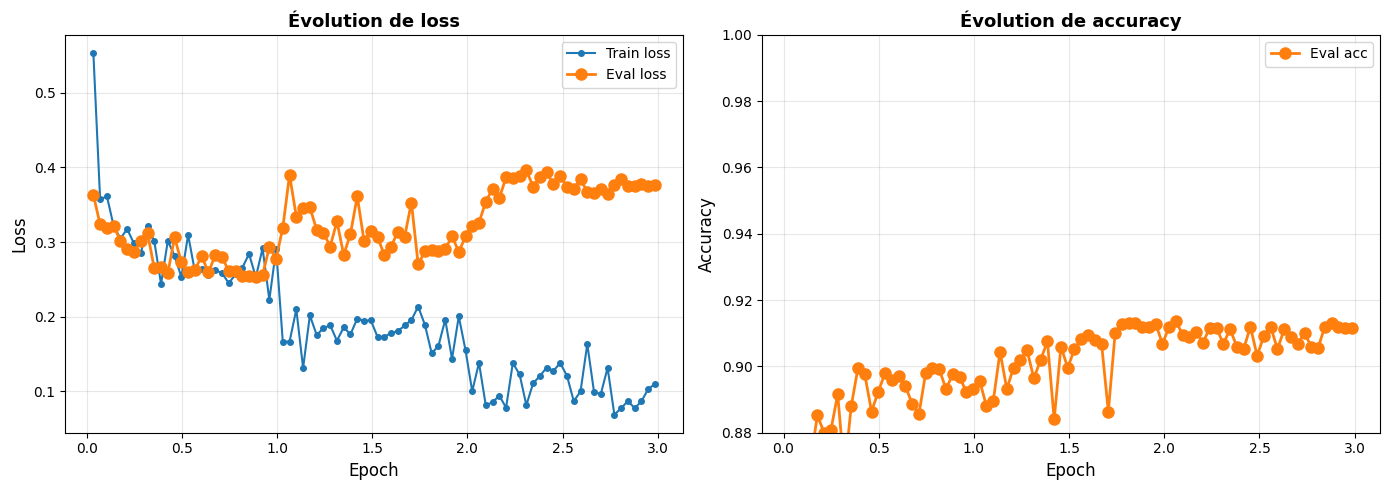

In [37]:
from pathlib import Path
import json

metrics_path = Path("out/training_metrics.json")

with open(metrics_path, "r") as f:
    metrics = json.load(f)

train_logs = metrics["train_logs"]
eval_logs = metrics["eval_logs"]

# extraction du data
train_epochs = [log["epoch"] for log in train_logs]
train_losses = [log["loss"] for log in train_logs]

eval_epochs = [log["epoch"] for log in eval_logs]
eval_losses = [log["eval_loss"] for log in eval_logs]
eval_accs = [log["eval_accuracy"] for log in eval_logs]

# PLOT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss (train = tous les steps, eval = fin d'epoch)
ax1.plot(train_epochs, train_losses, marker='o', label='Train loss', color='#1f77b4', markersize=4, linewidth=1.5)
ax1.plot(eval_epochs, eval_losses, marker='o', label='Eval loss', color='#ff7f0e', markersize=8, linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Évolution de loss', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy (just eval, pas de train accuracy disponible dans les logs.... )
ax2.plot(eval_epochs, eval_accs, marker='o', label='Eval acc', color='#ff7f0e', markersize=8, linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Évolution de accuracy', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.88, 1.0])

plt.tight_layout()
plt.show()

## Import

In [19]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import Trainer, DataCollatorWithPadding
from sklearn.metrics import confusion_matrix
import torch
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path


MODEL_PATH = "out/model_a"
SEED = 42
MAX_LENGTH = 256


tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)


dataset = load_dataset("imdb")


def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


# HuggingFace IMDB a un sous-enssemble pour TRAIN, TEST et UNSUPERVISED...
test_ds = dataset["test"].map(tokenize_function, batched=True, remove_columns=["text"])

In [20]:
first_positive_review = dataset["test"].filter(lambda review: review["label"] == 1)[0]
first_negative_review = dataset["test"].filter(lambda review: review["label"] == 0)[0]

print("\nPREMIER AVIS POSITIF:\n")
print(f"Label: {first_positive_review['label']}\n")
print(f"Avis: {first_positive_review['text']}\n")

print("\nPREMIER AVIS NEGATIF:\n")
print(f"Label: {first_negative_review['label']}\n")
print(f"Avis: {first_negative_review['text']}")


PREMIER AVIS POSITIF:

Label: 1

Avis: Previous reviewer Claudio Carvalho gave a much better recap of the film's plot details than I could. What I recall mostly is that it was just so beautiful, in every sense - emotionally, visually, editorially - just gorgeous.<br /><br />If you like movies that are wonderful to look at, and also have emotional content to which that beauty is relevant, I think you will be glad to have seen this extraordinary and unusual work of art.<br /><br />On a scale of 1 to 10, I'd give it about an 8.75. The only reason I shy away from 9 is that it is a mood piece. If you are in the mood for a really artistic, very romantic film, then it's a 10. I definitely think it's a must-see, but none of us can be in that mood all the time, so, overall, 8.75.


PREMIER AVIS NEGATIF:

Label: 0

Avis: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is 

## Matrice de confusion

In [22]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8
)

trainer = Trainer(
    model=model,
    data_collator=data_collator,
    processing_class=tokenizer,
)

pred_output = trainer.predict(test_ds)

y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)

/Users/kourto/repositories/sdd1004/sdd1004-transformer-projet-fin-de-session/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [23]:
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

print("\nMatrice de confusion:")
print(cm)

TN = 11397
FP = 1103
FN = 1085
TP = 11415

Matrice de confusion:
[[11397  1103]
 [ 1085 11415]]


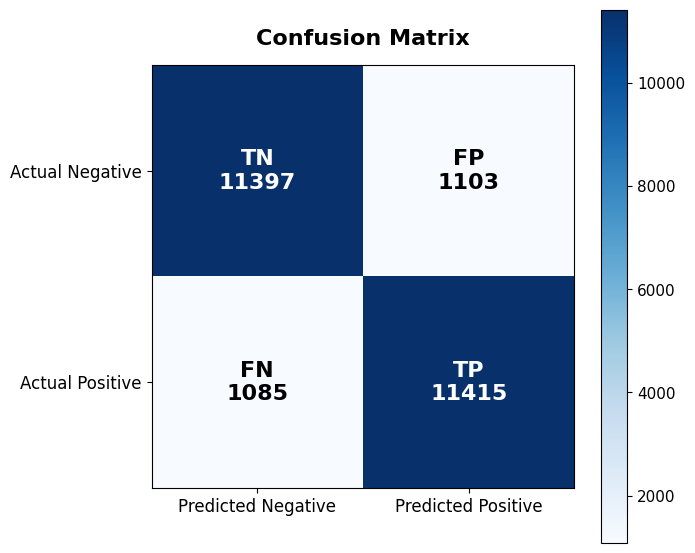

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

labels = np.array([
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
])

max_val = cm.max()

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > max_val / 2 else "black"
        ax.text(j, i, labels[i, j], ha="center", va="center", fontsize=16, fontweight="bold", color=color)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted Negative", "Predicted Positive"], fontsize=12)
ax.set_yticklabels(["Actual Negative", "Actual Positive"], fontsize=12)
ax.set_title("Confusion Matrix", fontsize=16, fontweight="bold", pad=15)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

### Analyse rapide de la matrice de confusion

- La matrice de confusion montre que le modèle classe correctement une grande majorité des avis de IMDB
- Le modèle semble avoir des bonnes prédictions des deux côtés, positif comme négatif
- un nombre d'erreurs relativement bas.

## Métriques d'évaluations

$$
\text{Loss} = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]
$$

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

In [25]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary"
)
accuracy = accuracy_score(y_true, y_pred)
loss = pred_output.metrics["test_loss"]

print(f"Loss     : {loss:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Loss     : 0.2717
Accuracy : 0.9125
Precision: 0.9119
Recall   : 0.9132
F1-score : 0.9125


### Analyse rapide des différentes métriques

- Les résultats montrent que le modèle a de bonnes performances sur les données de IMDB.
- L'accuracy de *91.25%* et les scores de precision, recall et F1 sont tous proche de la valeur de accuracy, le modèle semble plutôt équilibré.
- Le loss plutôt faible montre aussi que les prédictions du modèle restent généralement cohérentes avec les labels attendues...
- **Mais** avoir de bonnes performances ne veut pas dire qu'il y a un absence de biais ou qu'il n'est pas vulnérable face à des examples adversariaux.

## Les probabilités de confiance

$$
\mathbf{p}^{(i)} = \mathrm{softmax}(\mathbf{z}^{(i)})
$$

$$
p^{(i)}_j = \frac{e^{z^{(i)}_j}}{\sum_{k=1}^{C} e^{z^{(i)}_k}}
$$

$$
c_i = \max_j \left( p^{(i)}_j \right)
$$

$$
\text{Confiance moyenne} = \frac{1}{N} \sum_{i=1}^{N} c_i
$$

$$
\text{Confiance minimale} = \min_{1 \le i \le N} c_i
$$

$$
\text{Confiance maximale} = \max_{1 \le i \le N} c_i
$$

In [26]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8
)

trainer = Trainer(
    model=model,
    data_collator=data_collator,
    processing_class=tokenizer,
)

pred_output = trainer.predict(test_ds)

logits = pred_output.predictions
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

max_confidence = probs.max(axis=1)

print(f"Confiance moyenne: {max_confidence.mean():.4f}")
print(f"Confiance minimale: {max_confidence.min():.4f}")
print(f"Confiance maximale: {max_confidence.max():.4f}")

/Users/kourto/repositories/sdd1004/sdd1004-transformer-projet-fin-de-session/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Confiance moyenne: 0.9663
Confiance minimale: 0.5003
Confiance maximale: 0.9979


## Les exemples les plus confiants

In [27]:
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=1)

df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label": y_true,
    "pred_label": y_pred,
    "confidence": max_confidence
})

print("Les 5 predictions les plus confiante: ")
print(df.sort_values("confidence", ascending=False)[["confidence", "true_label", "pred_label", "text"]].head(5))

Les 5 predictions les plus confiante: 
       confidence  true_label  pred_label  \
23774    0.997878           1           1   
15306    0.997875           1           1   
19748    0.997874           1           1   
15801    0.997847           1           1   
17692    0.997822           1           1   

                                                    text  
23774  "Boogie Nights" is a masterpiece it tells a gr...  
15306  I have not seen a better comedy than the King ...  
19748  This was the best movie ever has seen on "Germ...  
15801  This show is my absolute favorite. This show i...  
17692  This is an excellent movie and should be prese...  


## Les exemples les moins confiants

In [28]:
print("\nLes 5 predictions les moins confiante:")
print(df.sort_values("confidence", ascending=True)[["confidence", "true_label", "pred_label", "text"]].head(5))


Les 5 predictions les moins confiante:
       confidence  true_label  pred_label  \
13765    0.500274           1           1   
14579    0.500298           1           0   
24402    0.500324           1           0   
21145    0.500454           1           0   
19602    0.500504           1           1   

                                                    text  
13765  One of the best 'guy' movies I've ever seen ha...  
14579  Until today, I thought there only three people...  
24402  I just got the DVD for Hardware Wars, in a shi...  
21145  Bud Abbott and Lou Costello always had a good ...  
19602  The last of the sequels,not counting Abbott an...  


## Cinq erreurs avec des probabilités de confiance élevées

In [32]:
errors_df = df[df["true_label"] != df["pred_label"]].copy()
high_conf_errors = errors_df.sort_values("confidence", ascending=False)

print("5 erreurs avec la plus forte confiance:")
for i, row in high_conf_errors.head(5).iterrows():
    print(f"\nConfiance: {row['confidence']:.4f}")
    print(f"Vrai label: {row['true_label']} | Prediction: {row['pred_label']}")
    print(f"Texte: {row['text'][:500]}")

5 erreurs avec la plus forte confiance:

Confiance: 0.9975
Vrai label: 0 | Prediction: 1
Texte: This is definitely one of the best Kung fu movies in the history of Cinema. The screenplay is really well done (which is not often the case for this type of movies) and you can see that Chuck (in one of his first role)is a great actor. The final fight with the sherif deputy in the bullring is a masterpiece!

Confiance: 0.9974
Vrai label: 0 | Prediction: 1
Texte: 'Ernest Saves Christmas' is comedian Ernest's Christmas special film. In this film, Ernest has to find a successor to Santa Claus in order for Christmas to continue. Along the way, he meets a young girl who is a thief and who ends up stealing something very important of Santa's (I won't tell you what that is; you'll just have to watch the film for yourself). Like most Ernest films, there is a lot of slapstick humor involved.<br /><br />This film is probably one of Ernest's best films. It's funny

Confiance: 0.9973
Vrai label: 1 | Pre

## Test du modèle sur quelques avis

In [31]:
sample_texts = [
    "This movie was absolutely wonderful, I loved every minute of it.", # POSITIVE
    "This was one of the worst movies I have ever seen.", # NEGATIVE
    "The acting was good, but the story was boring.", # NEGATIVE
    "I expected something terrible, but it was actually quite decent.", # POSITIVE
    "Not bad at all, even if some parts were disappointing." # POSITIVE
]

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

model = model.to(device)

inputs = tokenizer(
    sample_texts,
    truncation=True,
    padding=True,
    max_length=256,
    return_tensors="pt"
)

inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)

preds = torch.argmax(probs, dim=1).tolist()
probs = probs.cpu().tolist()

for text, pred, prob in zip(sample_texts, preds, probs):
    label = "Positive" if pred == 1 else "Negative"
    print(f"\nText: {text}")
    print(f"Prediction: {label}")
    print(f"Probabilities: Negative={prob[0]:.4f}, Positive={prob[1]:.4f}")

Using device: mps

Text: This movie was absolutely wonderful, I loved every minute of it.
Prediction: Positive
Probabilities: Negative=0.0033, Positive=0.9967

Text: This was one of the worst movies I have ever seen.
Prediction: Negative
Probabilities: Negative=0.9963, Positive=0.0037

Text: The acting was good, but the story was boring.
Prediction: Negative
Probabilities: Negative=0.9936, Positive=0.0064

Text: I expected something terrible, but it was actually quite decent.
Prediction: Positive
Probabilities: Negative=0.0312, Positive=0.9688

Text: Not bad at all, even if some parts were disappointing.
Prediction: Positive
Probabilities: Negative=0.1503, Positive=0.8497
